# SBI + Diffusion models

In [1]:
import torch
import numpy as np
import numba
from scipy import stats
import warnings
import sbi.utils as utils
from sbi.inference.base import infer

2024-07-08 17:38:48.754253: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-08 17:38:49.402251: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Import the bval and bvec. Check the format, because the format will be used in the following steps

In [2]:
bval = np.loadtxt('./bvals') 
bvec = np.loadtxt('./bvecs')
bval=bval
bvec=bvec.T
print(bval)
#print(bvec)

[   5. 1000. 2005. 1000. 1990.  995. 2000.  990. 2000.  995. 1995. 1005.
 2010. 1005. 2000.  995. 2000. 1005. 1995.  995. 2005.    5.  990. 1990.
 1000. 2000. 1005. 1990. 1000. 1985.  995. 1995. 1000. 1995. 1000. 2000.
 1000. 2005.  995. 1990. 1000. 1990.    5.  990. 2000.  990. 1995. 1000.
 1990.  990. 1995. 1000. 1995.  995. 1995.  995. 1995.  995. 2005. 1000.
 1995. 1005. 1990.    5.  995. 2000. 1000. 2005. 1000. 1990.  995. 1985.
 1000. 1990. 1000. 2000. 1005. 2010. 1005. 1995. 1005. 2005. 1000. 2000.
    5. 1005. 2000. 1000. 2000.  995. 2005. 1000. 2000. 1005. 2005. 1000.
 2010.  995. 2005. 1005. 1990. 1005. 1995. 1000. 1990.]


# Import the diffusion model, this is the code from Hossein

In [3]:
#!/usr/bin/env python3
"""
This module contains definition of some microstructural diffusion models and a prior distribution for their parameters.
"""

import numba
import numpy as np
from scipy import stats
import warnings

# prior distributions:
dif_coeff = 1.7  # unit: um^2/ms


def sample_signal(n_samples):
    """
    samples signal fraction parameters for 3 compartment models.
    :param n_samples: number of required samples
    :return: samples (n_samples, 3)
    """
    tissue_type = np.random.choice(3, n_samples, p=[0.0, .2, .8])
    # 0: Pure CSF, 1: CSF partial volume , 2: brain tissue
    s_iso = stats.uniform(loc=0, scale=.9).rvs(n_samples)
    s_in = stats.truncnorm(loc=.5, scale=.2, a=-.4 / .2, b=1 / 0.2).rvs(n_samples)
    s_ex = stats.truncnorm(loc=.5, scale=.2, a=-.4 / .2, b=1 / 0.2).rvs(n_samples)

    # CSF:
    s_iso[tissue_type == 0] = 1 - 1e-4

    # inside brain (no CSF partial volume)
    s_iso[tissue_type == 2] = 1e-4

    norm = (1 - s_iso) / (s_in + s_ex)
    return s_iso, s_in * norm, s_ex * norm


prior_distributions = dict(
    ball={'d_iso': stats.truncnorm(loc=3, scale=.1, a=-3 / 0.1, b=np.Inf)},
    stick={'d_a': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf)},

    cigar={'d_a': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
           'd_r': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf)
           },

    watson_zeppelin_numerical={
        'd_a': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
        'd_r': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
        'odi': stats.beta(a=1, b=4)
    },

    bingham_zeppelin={'d_a': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                      'd_r': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                      'odi': stats.beta(a=1, b=4),
                      'odi2': stats.beta(a=1, b=4),
                      'psi': stats.uniform(loc=np.pi / 2, scale=np.pi / 4),
                      },

    ball_stick={'s_iso': stats.truncnorm(loc=.5, scale=.2, a=-.5 / .2, b=np.Inf),
                's_a': stats.truncnorm(loc=.5, scale=.2, a=-.5 / .2, b=np.Inf),
                'd_iso': stats.truncnorm(loc=3, scale=.1, a=-3 / 0.1, b=np.Inf),
                'd_a': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                },

    standard_model={('s_iso', 's_in', 's_ex'): sample_signal,
                    'odi': stats.beta(a=2, b=3),
                    'd_iso': stats.truncnorm(loc=3, scale=.1, a=-3 / .1, b=np.Inf),
                    'd_in': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                    'd_ex': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                    'tau': stats.uniform(loc=0.01, scale=.98),
                    },

    standard_model_bingham={('s_iso', 's_in', 's_ex'): sample_signal,
                            'odi': stats.beta(a=2, b=3),
                            'odi_ratio': stats.uniform(loc=.01, scale=.98),
                            'd_iso': stats.truncnorm(loc=3, scale=.1, a=-3 / .1, b=np.Inf),
                            'd_in': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                            'd_ex': stats.truncnorm(loc=dif_coeff, scale=.3, a=-dif_coeff / 0.3, b=np.Inf),
                            'tau': stats.uniform(loc=0.01, scale=.98),
                            },

    noddi={('s_iso', 's_in', 's_ex'): sample_signal,
           'odi': stats.beta(a=2, b=5),
           },

    noddi_bingham={('s_iso', 's_in', 's_ex'): sample_signal,
                   'odi': stats.beta(a=1, b=4),
                   'odi_ratio': stats.uniform(loc=.01, scale=.98),
                   },
)


# compartment definitions:
def ball(bval, bvec, d_iso, s0=1.):
    """
    Simulates diffusion signal for isotropic diffusion

    This is the equation for this compartment:

    .. math::

        s = e^{-b d_{iso}}

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param d_iso: diffusion coefficient
    :param s0: attenuation for b=0
    :return: simulated signal (M,)
    """
    s0, d_iso = [np.asanyarray(v)[..., np.newaxis] for v in (s0, d_iso)]
    if not np.all(s0 >= 0):
        warnings.warn('s0 cant be negative')
    if not np.all(d_iso >= 0):
        warnings.warn('d_iso cant be negative')
    
    if not np.isscalar(bval):
        bval = bval * np.ones(bvec.shape[0])
    
    return s0 * np.exp(-bval * d_iso)


def stick(bval, bvec, d_a, theta, phi, s0=1.0):
    """
    Simulates diffusion signal from single stick model

    The attenuation for the stick is :math:`s=e^{-b d_a (\vec{g} \vec{n})^2}`.

    Simpler equation :math:`a=b`.

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param d_a: axial diffusion coefficient
    :param theta: angle from z-axis
    :param phi: angle from x axis in xy-plane
    :param s0: attenuation for b=0
    :return: simulated signal (M,)
    """
    s0, d_a, theta, phi = [np.asarray(v)[..., np.newaxis] for v in (s0, d_a, theta, phi)]
    if not np.all(d_a >= 0):
        warnings.warn("d_a can't be negative")
    if not np.all(s0 >= 0):
        warnings.warn("s0 cant be negative")

    orientation = np.array(spherical2cart(theta, phi)).T
    return s0 * np.exp(-bval * (d_a * orientation.dot(bvec.T) ** 2))


def cigar(bval, bvec, d_a, d_r, theta=0., phi=0, s0=1.0):
    """
    Simulates diffusion signal from single stick model

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param theta: angle from z-axis
    :param phi: angle from x axis in xy-plane
    :param d_a: axial diffusion coefficient
    :param d_r: radial diffusion coefficient
    :param s0: attenuation for b=0
    :return: simulated signal (M,)
    """
    s0, d_a, d_r = [np.asanyarray(v)[..., np.newaxis] for v in (s0, d_a, d_r)]
    if not np.all(d_r >= 0):
        warnings.warn("d_r can't be negative")
    if not np.all(d_a >= 0):
        warnings.warn("d_a can't be negative")
    if not np.all(s0 >= 0):
        warnings.warn("s0 cant be negative")

    orientation = spherical2cart(theta, phi)
    return s0 * np.exp(-bval * (d_r + (d_a - d_r) * bvec.dot(orientation) ** 2))


def bingham_zeppelin(bval, bvec, d_a, d_r, odi, odi2=None, theta=0., phi=0., psi=0., s0=1.):
    """
    Simulates diffusion signal for a zeppelin that is dispersed with a bingham distribution

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param d_a: axial diffusion coefficient
    :param d_r: radial diffusion coefficient
    :param odi: first dispersion coefficient
    :param odi2: second dispersion coefficient
    :param theta: theta for main diffusion direction
    :param phi: phi for main diffusion direction
    :param psi: first dispersion orientation
    :param s0: attenuation for b=0
    :return: simulated signal (M,)
    """
    if odi2 is None:
        odi2 = odi  # make it watson distribution.

    s0, d_a, d_r, odi, odi2, theta, phi, psi = [np.atleast_1d(v) for v in
                                                (s0, d_a, d_r, odi, odi2, theta, phi, psi)]
    n_samples = s0.shape[0]

    if not np.all(s0 >= 0):
        warnings.warn('s0 cannot be negative')

    if not np.all((odi >= odi2) & (odi2 > 0)):
        warnings.warn('odis must be positive and in order')

    if bvec.ndim == 1:
        bvec = bvec[np.newaxis, :]

    r_psi = np.array([[np.cos(psi), np.sin(psi), np.zeros_like(psi)],
                      [-np.sin(psi), np.cos(psi), np.zeros_like(psi)],
                      [np.zeros_like(psi), np.zeros_like(psi), np.ones_like(psi)]]).transpose()

    r_theta = np.array([[np.cos(theta), np.zeros_like(theta), -np.sin(theta)],
                        [np.zeros_like(theta), np.ones_like(theta), np.zeros_like(theta)],
                        [np.sin(theta), np.zeros_like(theta), np.cos(theta)]]).transpose()

    r_phi = np.array([[np.cos(phi), np.sin(phi), np.zeros_like(phi)],
                      [-np.sin(phi), np.cos(phi), np.zeros_like(phi)],
                      [np.zeros_like(phi), np.zeros_like(phi), np.ones_like(phi)]]).transpose()

    r = r_psi @ r_theta @ r_phi

    k1 = 1 / np.tan(odi * np.pi / 2)
    k2 = 1 / np.tan(odi2 * np.pi / 2)
    b_diag = np.zeros(k1.shape + (3, 3))
    b_diag[..., 0, 0] = -k1
    b_diag[..., 1, 1] = -k2

    if r.shape[0] == 1:
        bing_mat = np.array([r[0].T @ b_diag[i] @ r[0] for i in range(b_diag.shape[0])])
    elif r.shape[0] == n_samples:
        bing_mat = np.array([r[i].T @ b_diag[i] @ r[i] for i in range(b_diag.shape[0])])

    denom = hyp_sapprox(np.stack([np.zeros_like(k1), -k2, -k1], -1))
    q = bing_mat[:, np.newaxis, :, :] - (bval * (d_a - d_r)[..., np.newaxis])[..., np.newaxis, np.newaxis] * \
        ((bvec[:, np.newaxis, :] * bvec[:, :, np.newaxis])[np.newaxis, ...])
    num = hyp_sapprox(np.linalg.eigvalsh(q)[..., ::-1]) * np.exp(-d_r[..., np.newaxis] * bval)

    return s0[:, np.newaxis] * num / denom[:, np.newaxis]


def watson_zeppelin_numerical(bval, bvec, d_a, d_r, odi, theta=0., phi=0., s0=1., n_samples=10000):
    """
    Simulates diffusion signal for a zeppelin that is dispersed watson distribution using numerical integration

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param d_a: axial diffusion coefficient
    :param d_r: radial diffusion coefficient
    :param odi: first dispersion coefficient
    :param theta: theta for main diffusion direction
    :param phi: phi for main diffusion direction
    :param s0: attenuation for b=0
    :param n_samples: resolution of the surface integral
    :return: simulated signal (M,)
    """
    if not odi > 0:
        warnings.warn('odis must be positive')

    if bvec.ndim == 1:
        bvec = bvec[np.newaxis, :]

    if np.isscalar(bval):
        bval = bval * np.ones(bvec.shape[0])

    k = 1 / np.tan(odi * np.pi / 2)
    mu = np.array(spherical2cart(theta, phi))

    theta_samples, phi_samples = uniform_sampling_sphere(n_samples=n_samples)
    normal_samples = np.array(spherical2cart(theta_samples, phi_samples)).T
    wat_pdf_samples = np.exp(k * normal_samples.dot(mu) ** 2)
    wat_pdf_samples = wat_pdf_samples / wat_pdf_samples.sum()

    s = np.zeros_like(bval)
    for g_i, (b, g) in enumerate(zip(bval, bvec)):
        resp = cigar(b, g, d_a=d_a, d_r=d_r, theta=theta_samples, phi=phi_samples, s0=s0)
        s[g_i] = (resp * wat_pdf_samples).sum()
    return np.array(s)


# multi-compartment models:

def ball_stick(bval, bvec, d_a, d_iso, s_a, s_iso, theta=0., phi=0.0, s0=1.0):
    """
    Simulates diffusion signal from ball and stick model

    :param bval: acquisition b-value
    :param bvec: acquisition b-vec (M,3)
    :param theta: angle from z-axis
    :param phi: angle from x axis in xy-plane
    :param d_a: axial diffusion coefficient
    :param d_iso: radial diffusion coefficient
    :param s_iso: signal fraction of isotropic diffusion
    :param s_a:  signal fraction of anisotropic diffusion
    :param s0: attenuation for b=0
    :return: simulated signal (M,)
    """
    if not np.all(s_iso >= 0):
        warnings.warn('volume fraction cant be negative.')
    if not np.all(s_a >= 0):
        warnings.warn('volume fraction cant be negative')

    s_a = np.atleast_1d(s_a)
    s_iso = np.atleast_1d(s_iso)
    return stick(bval, bvec, d_a, theta, phi, s0) * s_a[:, np.newaxis] \
           + ball(bval, bvec, d_iso, s0) * s_iso[:, np.newaxis]


def standard_model(bval, bvec, s_iso, s_in, s_ex,
                   d_iso, d_in, d_ex,
                   tau, odi,
                   theta=0., phi=0., s0=1.):
    """
    Simulates diffusion signal with Watson dispersed standard model

    :param bval: b-values
    :param bvec: (,3) gradient directions(x, y, z)
    :param s_iso: signal fraction of isotropic diffusion
    :param s_in: signal fraction of intra-axonal diffusion
    :param s_ex: signal fraction of extra-axonal water
    :param d_iso: isotropic diffusion coefficient
    :param d_in: axial diffusion coefficient
    :param d_ex: axial diffusion coefficient for extra-axonal compartment
    :param tau: ratio of radial to axial diffusivity
    :param odi: dispersion parameter of watson distribution
    :param theta: orientation of stick from z axis
    :param phi: orientation of stick from x axis
    :param s0: attenuation for b=0
    :return: (M,) diffusion signal
    """
    if not s0 >= 0:
        warnings.warn('s0 cant be negative')
    a_iso = ball(bval=bval, bvec=bvec, d_iso=d_iso, s0=s_iso)
    a_int = bingham_zeppelin(bval=bval, bvec=bvec, d_a=d_in, d_r=0,
                             odi=odi, odi2=odi,
                             psi=0, theta=theta, phi=phi, s0=s_in)

    a_ext = bingham_zeppelin(bval=bval, bvec=bvec, d_a=d_ex,
                             d_r=d_ex * tau,
                             odi=odi, odi2=odi,
                             psi=0, theta=theta, phi=phi, s0=s_ex)

    return (a_iso + a_int + a_ext) * s0


def standard_model_bingham(bval, bvec,
                           s_iso, s_in, s_ex,
                           d_iso, d_in, d_ex, tau,
                           odi, odi_ratio, psi=0., theta=0., phi=0., s0=1.):
    """
    Simulates diffusion signal with Bingham dispressed NODDI model

    :param bval: b-values
    :param bvec: (,3) gradient directions(x, y, z)
    :param s_iso: signal fraction of isotropic diffusion
    :param s_in: signal fraction of intra-axonal diffusion
    :param s_ex: signal fraction of extra-axonal water
    :param d_iso: isotropic diffusion coefficient
    :param d_in: axial diffusion coefficient
    :param d_ex: axial diffusion coefficient for extra-axonal compartment
    :param tau: ratio for radial diffusion coefficient for intra-axonal compartment
    :param odi: dispersion parameter of bingham distribution
    :param odi_ratio: ratio for dispersion parameter of bingham distribution
    :param psi: fanning orientation
    :param theta: orientation angle of stick from z axis
    :param phi: orientation angle of stick from x axis
    :param s0: attenuation for b=0
    :return: (M,) diffusion signal
        """

    a_iso = ball(bval=bval, bvec=bvec, d_iso=d_iso, s0=s_iso)

    a_int = bingham_zeppelin(bval=bval, bvec=bvec, d_a=d_in, d_r=0,
                             odi=odi, odi2=odi * odi_ratio,
                             psi=psi, theta=theta, phi=phi, s0=s_in)
    a_ext = bingham_zeppelin(bval=bval, bvec=bvec, d_a=d_ex, d_r=d_ex * tau,
                             odi=odi, odi2=odi * odi_ratio,
                             psi=psi, theta=theta, phi=phi, s0=s_ex)
    return (a_iso + a_int + a_ext) * s0


def noddi(bval, bvec, s_iso, s_in, s_ex, odi, theta=0., phi=0., s0=1.):
    # fixed parameters:
    d_iso = 3
    dax_int = 1.7
    dax_ext = 1.7
    tau = s_ex / (s_in + s_ex + np.finfo(s_in.dtype).eps)

    signal = standard_model(bval=bval, bvec=bvec,
                            s_iso=s_iso, s_in=s_in, s_ex=s_ex,
                            d_iso=d_iso, d_in=dax_int, d_ex=dax_ext,
                            tau=tau, odi=odi, s0=s0,
                            theta=theta, phi=phi)
    return signal


def bingham_noddi(bval, bvec, s_iso, s_in, s_ex, odi, odi_ratio, theta=0., phi=0., psi=0., s0=1.):
    # fixed parameters:
    d_iso = 3
    d_in = 1.7
    d_ex = 1.7
    tau = s_in / (s_in + s_ex)

    signal = standard_model_bingham(bval=bval, bvec=bvec,
                                    s_iso=s_iso, s_in=s_in, s_ex=s_ex,
                                    d_iso=d_iso, d_in=d_in, d_ex=d_ex,
                                    tau=tau, odi=odi, odi_ratio=odi_ratio, s0=s0,
                                    theta=theta, phi=phi, psi=psi)
    return signal


# helper functions:
def spherical2cart(theta, phi, r=1):
    """
    Converts spherical to cartesian coordinates
    :param theta: angel from z axis
    :param phi: angle from x axis
    :param r: radius
    :return: tuple [x, y, z]-coordinates
    """
    z = r * np.cos(theta)
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    return x, y, z


def cart2spherical(n):
    """
    Converts to spherical coordinates
    :param n: (:, 3) array containing vectors in (x,y,z) coordinates
    :return: tuple with (phi, theta, r)-coordinates
    """
    r = np.sqrt(np.sum(n ** 2, axis=1))
    theta = np.arccos(n[:, 2] / r)
    phi = np.arctan2(n[:, 1], n[:, 0])
    phi[r == 0] = 0
    theta[r == 0] = 0
    return r, phi, theta


def uniform_grid_sphere(n_theta, n_phi=None):
    """
    Generates uniformly distributed grid over the surface of sphere:

    :param n_theta: number of theta grids
    :param n_phi: number of phi_grids
    :return: grid of theta and phi
    """
    if n_phi is None:
        n_phi = n_theta

    phi = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)

    cos_theta = np.linspace(-1, 1, n_theta)
    theta = np.arccos(cos_theta)

    pairs = np.array([(t, p) for t in theta for p in phi])
    theta, phi = pairs.T
    return theta, phi


def uniform_sampling_sphere(n_samples):
    """
    Generates uniformly distributed samples over the surface of sphere:

    :param n_samples: number of theta grids
    :return: samples of theta and phi
    """

    phi = np.random.uniform(0, 2 * np.pi, n_samples)

    cos_theta = np.random.uniform(-1, 1, n_samples)
    theta = np.arccos(cos_theta)
    return theta, phi


def plot_response_function(response, shells, idx_shells, bvecs, res=40, maxs=5):
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata
    from matplotlib import cm
    fig = plt.figure(figsize=(12, 8))

    for shell_idx in np.arange(1, 1):
        sig = - np.log(response[idx_shells == shell_idx]) / shells[shell_idx].bval
        dirs = bvecs[idx_shells == shell_idx]
        dirs = np.vstack((dirs, -dirs))
        sig = np.append(sig, sig)
        _, phi, theta = cart2spherical(dirs)

        p, t = np.meshgrid(np.linspace(-np.pi, np.pi, res), np.linspace(0, np.pi, res))
        s = griddata((phi, theta), sig, (p, t), method='nearest')
        x = np.sin(p) * np.cos(t)
        y = np.sin(p) * np.sin(t)
        z = np.cos(p)

        ax = fig.add_subplot(2, 2, shell_idx, projection='3d')
        plt.set_cmap('jet')
        plot = ax.plot_surface(
            x, y, z, rstride=1, cstride=1, cmap=cm.jet,
            linewidth=0, antialiased=False, alpha=.8, facecolors=cm.jet(s / maxs))
        plot.set_clim(vmin=0, vmax=maxs)
        fig.colorbar(plot, shrink=0.5, aspect=2)
        plt.title(f"bvals={shells[shell_idx].bval}")
        ax.set_xlim3d(-maxs, maxs), ax.set_ylim3d(-maxs, maxs), ax.set_zlim3d(-maxs, maxs)
        ax.view_init(azim=0, elev=0)
    plt.show()


@numba.jit(nopython=True)
def find_t(l1, l2, l3):
    """
    Helper function for hyp_Sapprox

    Args:
        l1: float
            negative first eigenvalue
        l2: float
            negative second eigenvalue
        l3: float
            negative third eigenvalue

    Returns: float
        I guess the return value is t

    """
    a3 = l1 * l2 + l2 * l3 + l1 * l3
    a2 = 1.5 - l1 - l2 - l3
    a1 = a3 - l1 - l2 - l3
    a0 = 0.5 * (a3 - 2 * l1 * l2 * l3)

    inv3 = 1. / 3.
    p = (a1 - a2 * a2 * inv3) * inv3
    q = (-9 * a2 * a1 + 27 * a0 + 2 * a2 * a2 * a2) / 54
    d = q * q + p * p * p
    offset = a2 * inv3

    if d > 0:
        ee = np.sqrt(d)
        z1 = (-q + ee) ** inv3 + (-q - ee) ** inv3 - offset
        z2 = z1
        z3 = z1
    elif d < 0:
        ee = np.sqrt(-d)
        angle = 2 * inv3 * np.arctan(ee / (np.sqrt(q * q + ee * ee) - q))
        sqrt3 = np.sqrt(3.)
        c = np.cos(angle)
        s = np.sin(angle)
        ee = np.sqrt(-p)
        z1 = 2 * ee * c - offset
        z2 = -ee * (c + sqrt3 * s) - offset
        z3 = -ee * (c - sqrt3 * s) - offset
    else:
        tmp = -q ** inv3
        z1 = 2 * tmp - offset
        if p != 0 or q != 0:
            z2 = tmp - offset
        else:
            z2 = z1
        z3 = z2
    if z1 < z2 and z1 < z3:
        return z1
    elif z2 < z3:
        return z2
    else:
        return z3


@numba.guvectorize([(numba.float64[:], numba.float64[:])], "(n)->()")
def hyp_sapprox(x, res):
    """
    Computes 1F1(1/2; 3/2; M) where ``x`` are the eigenvalues from M

    see ``der_hyp_Sapprox`` to only numerically estimate the derivative

    Args:
        x: (3, ) float np.ndarray
            eigenvalues in descending order

    Returns: float
        Result of the hypergeometric function

    """
    if x[0] == 0 and x[1] == 0 and x[2] == 0:
        res[0] = 1.
    else:
        t = find_t(-x[0], -x[1], -x[2])
        r = 1.
        k2 = 0.
        k3 = 0.
        k4 = 0.

        for idx in range(3):
            r /= np.sqrt(-x[idx] - t)
            k2 += 0.5 * (x[idx] + t) ** -2
            k3 -= (x[idx] + t) ** -3
            k4 += 3 * (x[idx] + t) ** -4

        tau = k4 / (8 * k2 * k2) - 5 * k3 * k3 / (24 * k2 ** 3)
        c1 = (np.sqrt(2 / k2) * np.pi * r * np.exp(-t)) * np.exp(tau) / (4 * np.pi)
        res[0] = c1


# Check the format of the output signals, because this will beused in the following steps

In [4]:
s_iso, s_in, s_ex = sample_signal(1)
print(s_iso, s_in, s_ex)

[0.0001] [0.62658392] [0.37331608]


In [5]:
odi = stats.beta(a=2, b=5)
print(odi.rvs(1))

[0.25600221]


In [6]:
noddi_prior = prior_distributions['noddi']
odi_prior = noddi_prior['odi']
print(noddi_prior)
print(odi_prior)

{('s_iso', 's_in', 's_ex'): <function sample_signal at 0x7743ce412830>, 'odi': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x774252a9c310>}


# Check th out put format of noddi

In [7]:
noddi(bval, bvec, s_iso, s_in, s_ex, odi.rvs(1), theta=0., phi=0., s0=2)

array([[1.47161572e-01, 8.52213333e-02, 2.22438182e-05, 4.26802331e-02,
        5.44708089e-04, 7.69568702e-04, 6.29346261e-02, 7.09802056e-05,
        6.03837529e-02, 4.06027365e-03, 4.70097686e-02, 3.57747906e-04,
        6.15380960e-05, 4.84364288e-03, 2.60931642e-02, 4.78988445e-02,
        4.65328231e-02, 2.61917152e-04, 4.44543631e-03, 4.84174297e-02,
        2.02928810e-03, 1.47161572e-01, 9.01925238e-05, 6.16849975e-04,
        2.18728155e-02, 6.53826373e-02, 9.15928400e-04, 1.82284284e-02,
        2.01779249e-02, 5.80497240e-05, 6.12395492e-03, 5.06816803e-02,
        3.16643440e-02, 2.54590823e-02, 7.88700015e-02, 1.25964182e-02,
        6.92468730e-02, 3.23506715e-03, 3.53202537e-03, 1.90120382e-04,
        9.12834387e-02, 1.41283327e-03, 1.47161572e-01, 5.20031130e-05,
        6.92003309e-03, 3.42514519e-05, 5.87162156e-03, 8.82701968e-02,
        1.96476671e-03, 5.24402355e-05, 5.19394620e-02, 1.75122642e-02,
        1.34214831e-02, 2.39484347e-03, 3.83262163e-02, 1.912273

In [8]:
print(noddi(bval, bvec, s_iso, s_in, s_ex, odi.rvs(1), theta=0., phi=0., s0=2).shape)

(1, 105)


Now it is only a easy case

# OK. Now is SBI with Noddi of Hossein. This steps we check the theta, phi and S

At first we set theta, phi and S0 to Uniform distribution

In [9]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer


# Forward model with NODDI
def forward(p):   
    th, ph, s = p
    s=s.item()
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi.rvs(1), theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


prior1 = utils.BoxUniform(low  =torch.tensor([-10,-10, 0.]), 
                         high =torch.tensor([ 10, 10, 3.]))

#print(prior)



inference = infer(forward, prior1, method='SNPE', num_simulations=1000,num_workers=8)

Running 1000 simulations in 1000 batches.:   0%|       | 0/1000 [00:00<?, ?it/s]2024-07-02 13:27:33.770220: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-02 13:27:33.802019: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-02 13:27:33.814894: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate 

 Neural network successfully converged after 90 epochs.

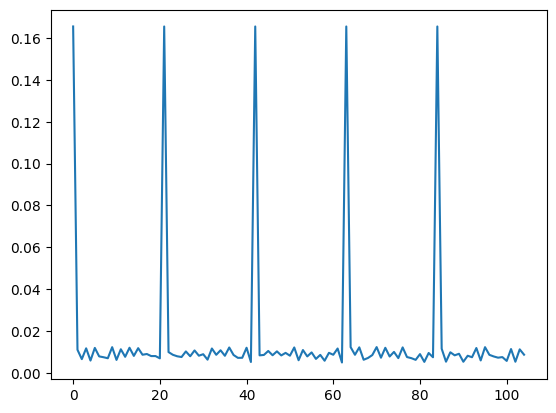

In [10]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0])
observation = forward(true_p)
plt.plot(observation)
plt.savefig('true_signal.png')

In [12]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 102576it [00:00, 200680.60it/s]               


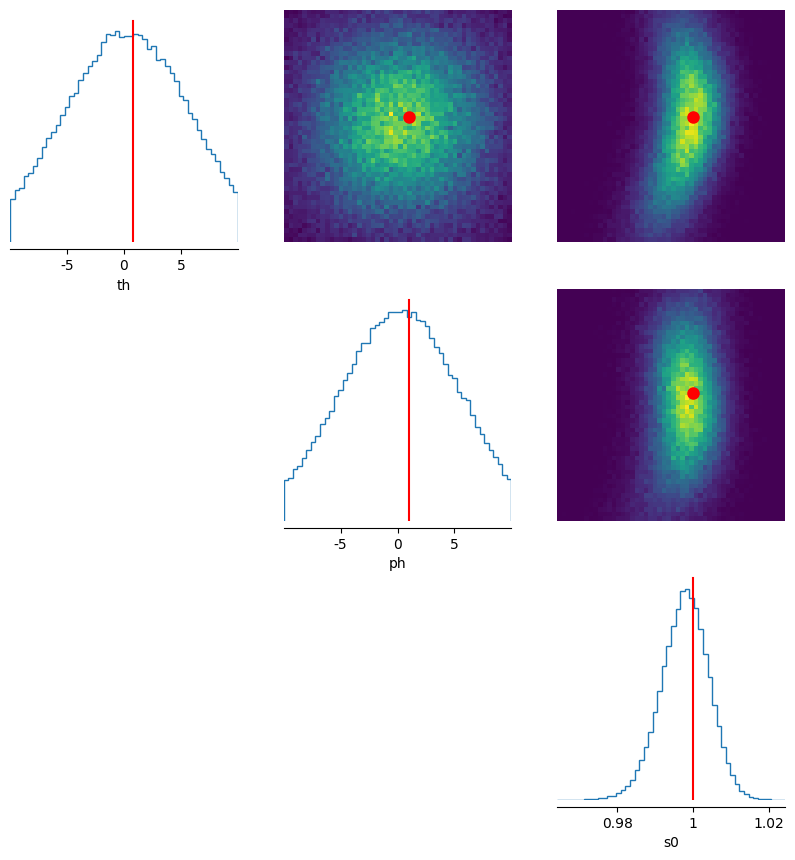

In [13]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Uniform.png')

In [14]:
# Now Use Gaussian distribution for the prior

In [15]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer


# Forward model with NODDI
def forward(p):   
    th, ph, s = p
    s=s.item()
    #print(s, ph,th)
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi.rvs(1), theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


import torch
from torch.distributions import MultivariateNormal

# Means for the Gaussian prior
means = torch.tensor([0.0, 0.0, 1.5])

# Standard deviations for the Gaussian prior
std_devs = torch.tensor([5.0, 5.0, 0.5])

# Covariance matrix for the Gaussian prior
cov_matrix = torch.diag(std_devs ** 2)

# Create the Multivariate Gaussian prior
gaussian_prior = MultivariateNormal(loc=means, covariance_matrix=cov_matrix)

#prior = utils.BoxUniform(low  =torch.tensor([-10,-10, 0.]),high =torch.tensor([ 10, 10, 3.]))

print(gaussian_prior)

# Example usage of the inference method with the defined model and priors
#inference = infer(simulator, prior, method='SNPE', num_simulations=1000,num_workers=8)

#prior = stats.beta(a=2, b=5).rvs(1)
#print(prior)

inference = infer(forward,  gaussian_prior, method='SNPE', num_simulations=1000,num_workers=8)

MultivariateNormal(loc: torch.Size([3]), covariance_matrix: torch.Size([3, 3]))


Running 1000 simulations in 1000 batches.:   9%| | 94/1000 [00:01<00:10, 88.07it/tmp/ipykernel_7739/1792688119.py:327: UserWarning: s0 cant be negative
Running 1000 simulations in 1000 batches.:  17%|▏| 172/1000 [00:02<00:14, 57.29i/tmp/ipykernel_7739/1792688119.py:327: UserWarning: s0 cant be negative
Running 1000 simulations in 1000 batches.:  98%|▉| 978/1000 [00:12<00:00, 81.96i/tmp/ipykernel_7739/1792688119.py:327: UserWarning: s0 cant be negative
Running 1000 simulations in 1000 batches.: 100%|█| 1000/1000 [00:12<00:00, 77.92


 Neural network successfully converged after 89 epochs.

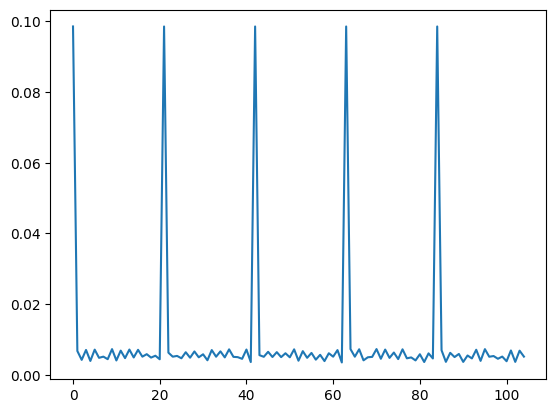

In [16]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0])
observation = forward(true_p)
plt.plot(observation)

In [17]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 100%|█| 100000/100000 [00:00<00:00, 247200.13i


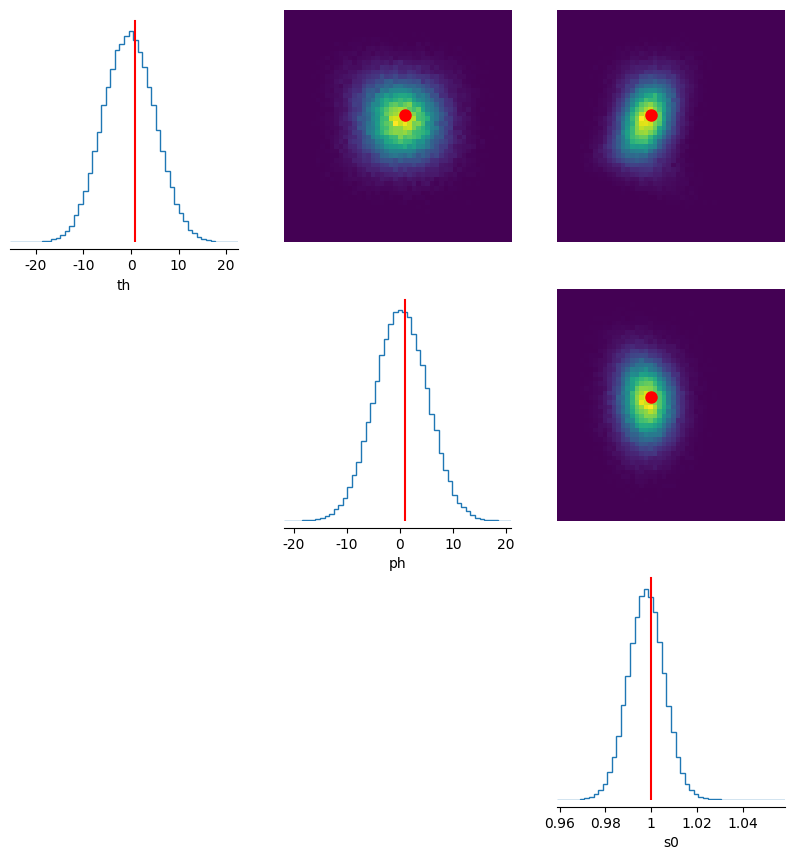

In [18]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Gaussian.png')

# Definitely Gaussian works better

# Now let us try different prior distribution

In [41]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer
from sbi.utils import MultipleIndependent


# Forward model with NODDI
def forward(p):   
    th, ph, s = p
    s=s.item()
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi.rvs(1), theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


import torch
from torch.distributions import MultivariateNormal
from torch.distributions import Normal, Uniform

# Define Gaussian priors for theta_1 and theta_2
gaussian_prior_theta1 = Normal(torch.tensor([0.0]), torch.tensor([1.0]))
gaussian_prior_theta2 = Normal(torch.tensor([1.0]), torch.tensor([0.5]))

# Define Uniform prior for theta_3 with batch_shape
uniform_prior_theta3 = Uniform(torch.tensor([0.0]), torch.tensor([10.0]))
combined_prior = MultipleIndependent([
    gaussian_prior_theta1,
    gaussian_prior_theta2,
    uniform_prior_theta3
])


print(combined_prior)

# Example usage of the inference method with the defined model and priors
#inference = infer(simulator, prior, method='SNPE', num_simulations=1000,num_workers=8)

#prior = stats.beta(a=2, b=5).rvs(1)
#print(prior)

inference = infer(forward,  combined_prior, method='SNPE', num_simulations=1000,num_workers=8)

MultipleIndependent()


Running 1000 simulations in 1000 batches.: 100%|█| 1000/1000 [00:13<00:00, 76.28


 Neural network successfully converged after 188 epochs.

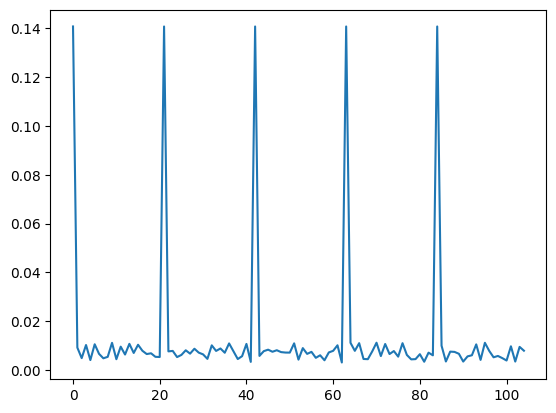

In [42]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0])
observation = forward(true_p)
plt.plot(observation)

In [43]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 100%|█| 100000/100000 [00:00<00:00, 242627.64i


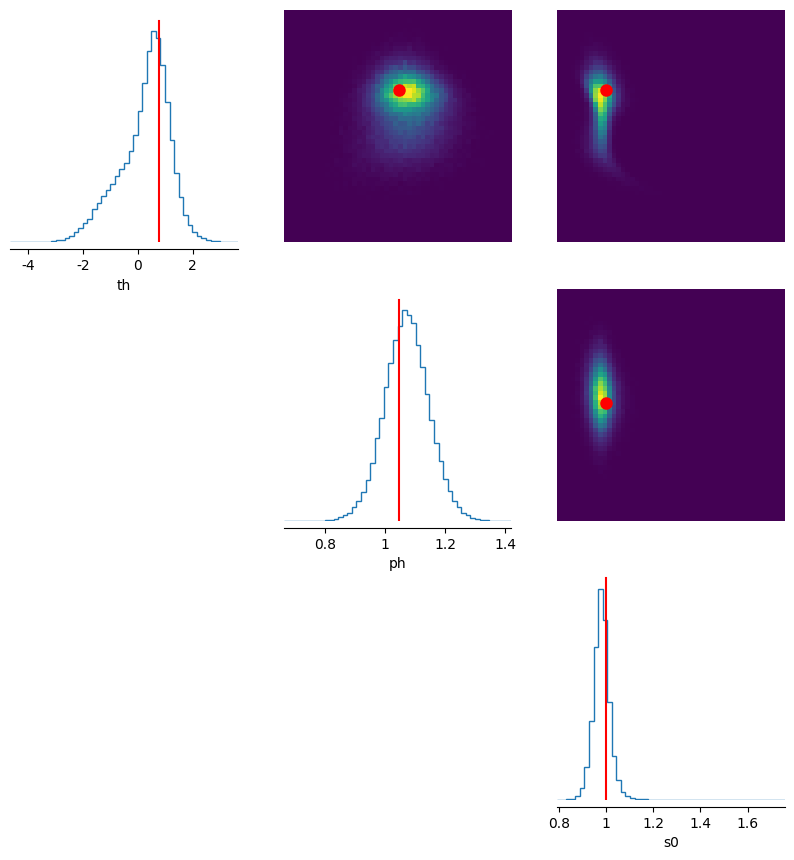

In [44]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Gaussian.png')

# Add ODI


In [7]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer
from sbi.utils import MultipleIndependent


# Forward model with NODDI
def forward(p):   
    th, ph, s, odi= p
    s=s.item()
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi, theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


import torch
from torch.distributions import MultivariateNormal
from torch.distributions import Normal, Uniform, Beta

# Define Gaussian priors for theta_1 and theta_2
gaussian_prior_theta1 = Normal(torch.tensor([0.0]), torch.tensor([1.0]))
gaussian_prior_theta2 = Normal(torch.tensor([1.0]), torch.tensor([0.5]))

# Define Uniform prior for theta_3 with batch_shape
uniform_prior_theta3 = Uniform(torch.tensor([0.0]), torch.tensor([10.0]))
beta_prior_odi = Beta(torch.tensor([2.0]), torch.tensor([5.0]))
combined_prior = MultipleIndependent([
    gaussian_prior_theta1,
    gaussian_prior_theta2,
    uniform_prior_theta3,
    beta_prior_odi
])


print(combined_prior)

# Example usage of the inference method with the defined model and priors
#inference = infer(simulator, prior, method='SNPE', num_simulations=1000,num_workers=8)

#prior = stats.beta(a=2, b=5).rvs(1)
print(combined_prior)

inference = infer(forward,  combined_prior, method='SNPE', num_simulations=1000,num_workers=8)

MultipleIndependent()
MultipleIndependent()


Running 1000 simulations in 1000 batches.:   0%|       | 0/1000 [00:00<?, ?it/s]2024-07-01 13:18:56.609039: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-01 13:18:56.614697: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-01 13:18:56.639099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use avai2024-07-01 13:18:56.639099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use avai2024-07-01 13:18:56.639104: I tensorflow

 Neural network successfully converged after 63 epochs.

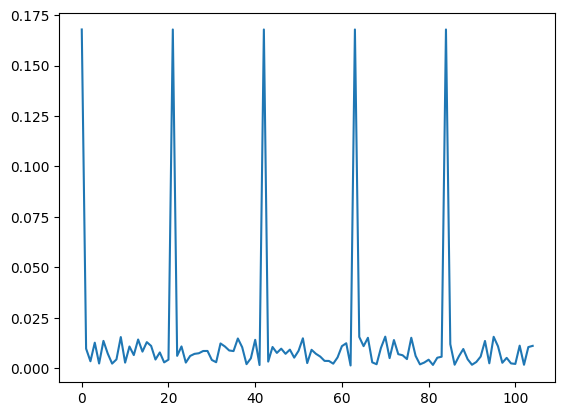

In [46]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0, 0.19])
observation = forward(true_p)
plt.plot(observation)

In [47]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 100079it [00:00, 194544.18it/s]               


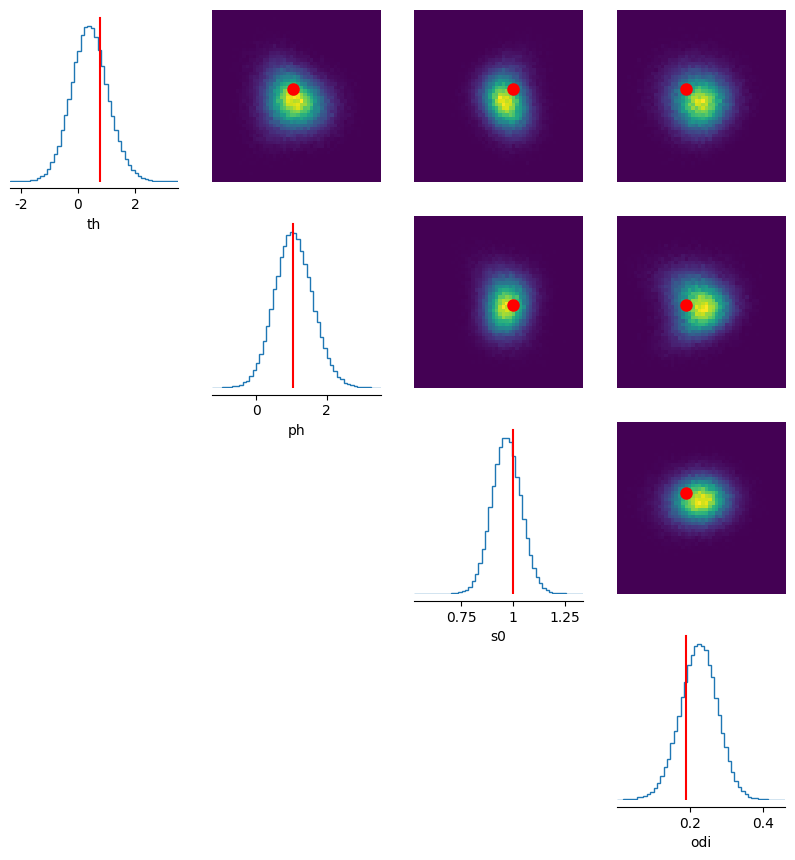

In [48]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0','odi'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Gaussian.png')

# Add all

In [50]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer
from sbi.utils import MultipleIndependent


# Forward model with NODDI
def forward(p):   
    th, ph, s, odi,s_iso= p
    s=s.item()
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi, theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


import torch
from torch.distributions import MultivariateNormal
from torch.distributions import Normal, Uniform, Beta

# Define Gaussian priors for theta_1 and theta_2
gaussian_prior_theta1 = Normal(torch.tensor([0.0]), torch.tensor([1.0]))
gaussian_prior_theta2 = Normal(torch.tensor([1.0]), torch.tensor([0.5]))

# Define Uniform prior for theta_3 with batch_shape
uniform_prior_theta3 = Uniform(torch.tensor([0.0]), torch.tensor([10.0]))
beta_prior_odi = Beta(torch.tensor([2.0]), torch.tensor([5.0]))
normal_prior_s_iso = Normal(torch.tensor([0.45]), torch.tensor([0.3]))  # mean=0.45, std=0.3
normal_prior_s_in = Normal(torch.tensor([0.7]), torch.tensor([0.1]))   # mean=0.7, std=0.1
normal_prior_s_ex = Normal(torch.tensor([0.7]), torch.tensor([0.1]))   # mean=0.7, std=0.1



combined_prior = MultipleIndependent([
    gaussian_prior_theta1,
    gaussian_prior_theta2,
    uniform_prior_theta3,
    beta_prior_odi,
    normal_prior_s_iso,
    #normal_prior_s_in,
    #normal_prior_s_ex
])


print(combined_prior)

# Example usage of the inference method with the defined model and priors
#inference = infer(simulator, prior, method='SNPE', num_simulations=1000,num_workers=8)

#prior = stats.beta(a=2, b=5).rvs(1)
#print(prior)

inference = infer(forward,  combined_prior, method='SNPE', num_simulations=1000,num_workers=8)

MultipleIndependent()


Running 1000 simulations in 1000 batches.:   0%|       | 0/1000 [00:00<?, ?it/s]2024-06-17 14:15:53.765241: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use avai2024-06-17 14:15:53.765241: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
lable CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-17 14:15:53.791908: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate 

 Neural network successfully converged after 48 epochs.

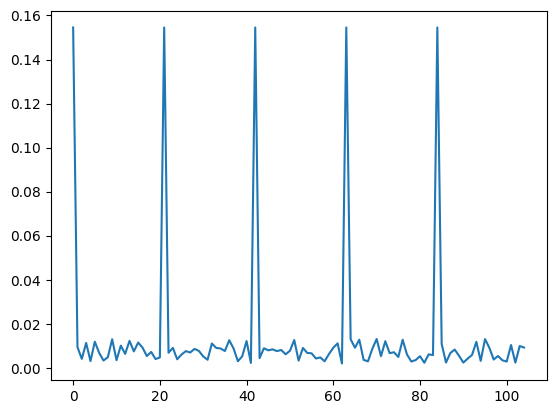

In [64]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0, 0.25,0.4])
observation = forward(true_p)
plt.plot(observation)

In [65]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 100053it [00:00, 149201.57it/s]               


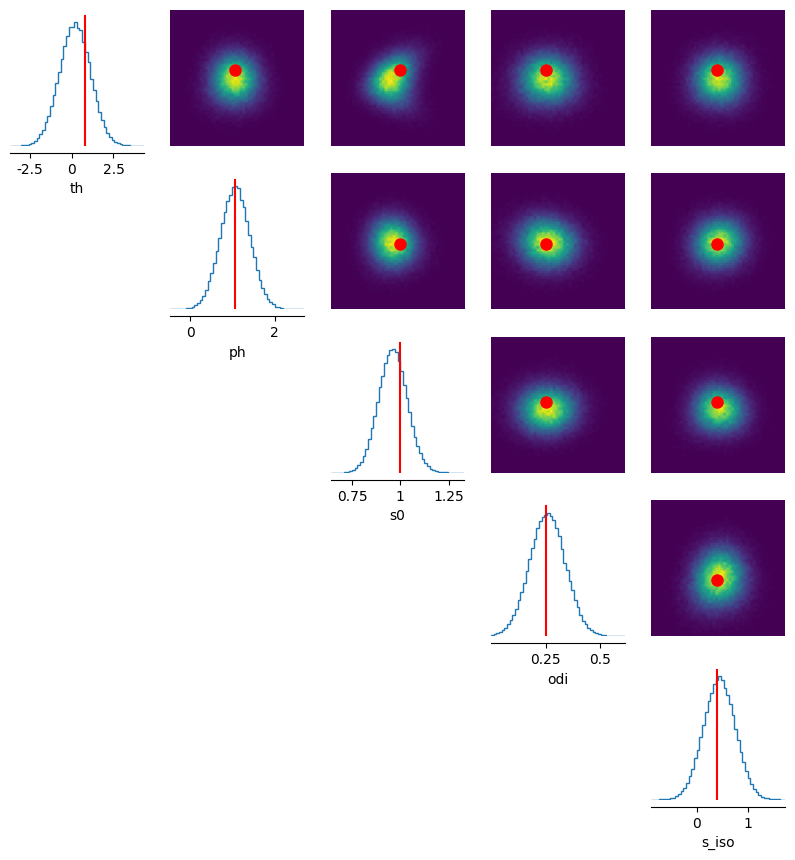

In [66]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0','odi','s_iso'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Gaussian.png')

In [70]:
# import torch
import numpy as np

import sbi.utils as utils
from sbi.inference.base import infer
from sbi.utils import MultipleIndependent


# Forward model with NODDI
def forward(p):   
    th, ph, s, odi,s_iso, s_in, s_ex= p
    s=s.item()
    s_in = s_in.numpy()
    s_ex = s_ex.numpy()
    signal = noddi(bval, bvec, s_iso, s_in, s_ex, odi, theta=th, phi=ph, s0=s).flatten() 
    #print(signal)
    return signal


# Priors (uniform in this case)
#  


import torch
from torch.distributions import MultivariateNormal
from torch.distributions import Normal, Uniform, Beta

# Define Gaussian priors for theta_1 and theta_2
gaussian_prior_theta1 = Normal(torch.tensor([0.0]), torch.tensor([1.0]))
gaussian_prior_theta2 = Normal(torch.tensor([1.0]), torch.tensor([0.5]))

# Define Uniform prior for theta_3 with batch_shape
uniform_prior_theta3 = Uniform(torch.tensor([0.0]), torch.tensor([10.0]))
beta_prior_odi = Beta(torch.tensor([2.0]), torch.tensor([5.0]))
normal_prior_s_iso = Normal(torch.tensor([0.45]), torch.tensor([0.3]))  # mean=0.45, std=0.3
normal_prior_s_in = Normal(torch.tensor([0.7]), torch.tensor([0.1]))   # mean=0.7, std=0.1
normal_prior_s_ex = Normal(torch.tensor([0.7]), torch.tensor([0.1]))   # mean=0.7, std=0.1



combined_prior = MultipleIndependent([
    gaussian_prior_theta1,
    gaussian_prior_theta2,
    uniform_prior_theta3,
    beta_prior_odi,
    normal_prior_s_iso,
    normal_prior_s_in,
    normal_prior_s_ex
])


print(combined_prior)


inference = infer(forward,  combined_prior, method='SNPE', num_simulations=1000,num_workers=8)

MultipleIndependent()


Running 1000 simulations in 1000 batches.:   0%|       | 0/1000 [00:00<?, ?it/s]2024-06-17 14:22:04.235610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-17 14:22:04.284164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-17 14:22:04.305480: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate 

 Neural network successfully converged after 77 epochs.

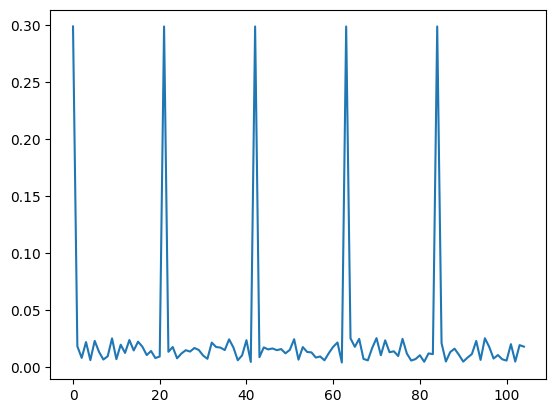

In [78]:
# Generate a new observation
import matplotlib.pyplot as plt
true_p = torch.tensor([0.7854, 1.0472, 1.0, 0.25,0.4,0.75,0.75])
observation = forward(true_p)
plt.plot(observation)

In [79]:
samples     = inference.sample((100000,), x=observation)

Drawing 100000 posterior samples: 100209it [00:00, 110165.60it/s]               


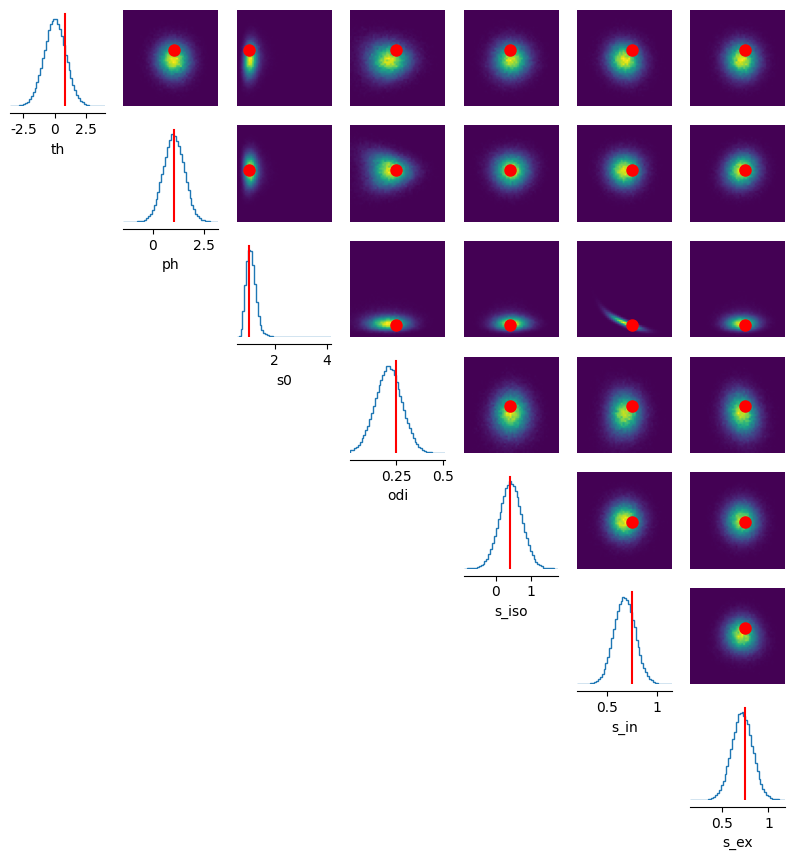

In [80]:
from sbi import utils as utils
from sbi import analysis as analysis
fig, axes = analysis.pairplot(samples,
                              fig_size=(15,15),
                              points=true_p, labels=['th', 'ph', 's0','odi','s_iso','s_in','s_ex'],
                              points_offdiag={'markersize': 16},
                              points_colors='r');
fig.savefig('Gaussian.png')

# Ok Now, let us try something new

In [15]:
def Help_distribution_sample_signal(prior):
    n_samples = 1
    s_iso0, s_in0, s_ex0, odi0, theta0, phi0, s00= prior
    odi = odi0.rvs(1)
    tissue_type = np.random.choice(3, n_samples, p=[0.0, .2, .8])
    # 0: Pure CSF, 1: CSF partial volume , 2: brain tissue
    s_iso = s_iso0.rvs(n_samples)
    s_in  = s_in0.rvs(n_samples)
    s_ex  = s_ex0.rvs(n_samples)
    theta = theta0
    phi   = phi0
    s0    = s00.item()

    # CSF:
    s_iso[tissue_type == 0] = 1 - 1e-4

    # inside brain (no CSF partial volume)
    s_iso[tissue_type == 2] = 1e-4

    norm = (1 - s_iso) / (s_in + s_ex)
    return s_iso, s_in * norm, s_ex * norm, odi, theta, phi, s0